## Importing Libraries

In [34]:
import os
from glob import glob

import numpy as np
import matplotlib.pyplot as plt

import cv2

from sklearn.model_selection import train_test_split

from tensorflow.keras.utils import to_categorical

---

## Importing Data for Understanding

In [35]:
# Setting paths of the dataset
image_dir = r"D:\Oxford Data\data\oxford-iiit-pet\images"  
trimap_dir = r"D:\Oxford Data\data\oxford-iiit-pet\annotations\trimaps"  

# Making lists of all image and trimap files
image_files = sorted(glob(os.path.join(image_dir, "*.jpg")))
trimap_files = sorted(glob(os.path.join(trimap_dir, "*.png")))

In [36]:
print(f"Number of images: {len(image_files)}")
print(f"Number of trimaps: {len(trimap_files)}")

Number of images: 7390
Number of trimaps: 7390


In [37]:
# Checking if the names are matching or not
for i in range(5):
    img_name = os.path.basename(image_files[i])
    trimap_name = os.path.basename(trimap_files[i])
    print(f"Image: {img_name}, Trimap: {trimap_name}")

Image: Abyssinian_1.jpg, Trimap: Abyssinian_1.png
Image: Abyssinian_10.jpg, Trimap: Abyssinian_10.png
Image: Abyssinian_100.jpg, Trimap: Abyssinian_100.png
Image: Abyssinian_101.jpg, Trimap: Abyssinian_101.png
Image: Abyssinian_102.jpg, Trimap: Abyssinian_102.png


---

## Visualizing Real Images & Trimaps

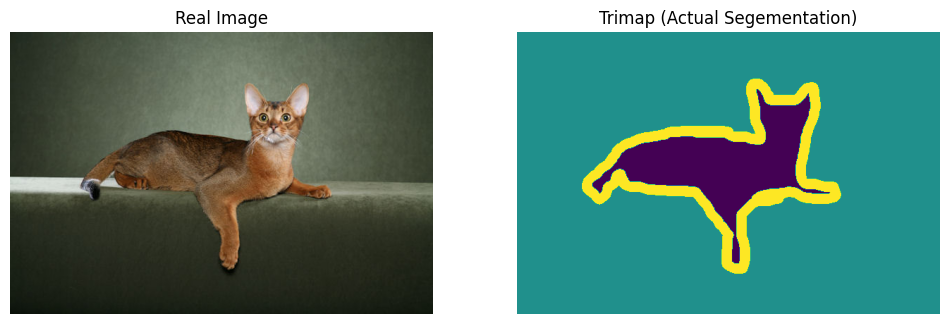

In [38]:
# Visualizing image and it's trimap
def visualize_sample(image_path, trimap_path):
   
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    trimap = cv2.imread(trimap_path, cv2.IMREAD_GRAYSCALE)
    
   
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Real Image")
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.imshow(trimap, cmap="viridis")
    plt.title("Trimap (Actual Segementation)")
    plt.axis("off")
    
    plt.show()

for i in range(1):
    visualize_sample(image_files[i], trimap_files[i])

---

## Preprocessing Images

In [39]:
# Processing the images
IMG_SIZE = 224

real_images = []  # Images
segmented_images = []  # Trimaps (Actual Segmentation)


num_samples = 1000 
sample_indices = np.random.choice(len(image_files), min(num_samples, len(image_files)), replace=False)

for idx in sample_indices:
    img_path = image_files[idx]
    trimap_path = trimap_files[idx]

    # Read and check if the image is valid
    img = cv2.imread(img_path)
    if img is None:
        print(f"Warning: Skipping unreadable image -> {img_path}")
        continue  # Skip unreadable images

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0  

    # Read and check if the trimap is valid
    trimap = cv2.imread(trimap_path, cv2.IMREAD_GRAYSCALE)
    if trimap is None:
        print(f"Warning: Skipping unreadable trimap -> {trimap_path}")
        continue  # Skip unreadable trimaps

    trimap = cv2.resize(trimap, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    trimap = trimap - 1  # Convert trimap values to zero-based indexing 

    real_images.append(img)
    segmented_images.append(trimap)

In [40]:
# Convert to numpy arrays
real_images = np.array(real_images, dtype=np.float32)
segmented_images = np.array(segmented_images, dtype=np.int32)

print(f"Preprocessed {real_images.shape[0]} images and {segmented_images.shape[0]} trimaps.")

Preprocessed 998 images and 998 trimaps.


In [ ]:
# One-hot encoding the labels
y_categorical = to_categorical(segmented_images, num_classes=3)

In [ ]:
print(f"X shape: {real_images.shape}")
print(f"y shape: {segmented_images.shape}")
print(f"y_categorical shape: {y_categorical.shape}")

X shape: (998, 224, 224, 3)
y shape: (998, 224, 224)
y_categorical shape: (998, 224, 224, 3)


In [42]:
# Splitting off the test set (10% of data)
x_temp, x_test, y_temp, y_test = train_test_split(real_images, y_categorical, test_size=0.1, random_state=42)

# SplitTING the remaining data into training (70%) and validation (20%)
x_train, x_val, y_train, y_val = train_test_split(x_temp, y_temp, test_size=0.22, random_state=42)

In [43]:
print(f"Training images: {x_train.shape[0]} ({x_train.shape[0]/real_images.shape[0]:.1%} of total)")
print(f"Validation images: {x_val.shape[0]} ({x_val.shape[0]/real_images.shape[0]:.1%} of total)")
print(f"Test images: {x_test.shape[0]} ({x_test.shape[0]/real_images.shape[0]:.1%} of total)")

Training images: 700 (70.1% of total)
Validation images: 198 (19.8% of total)
Test images: 100 (10.0% of total)


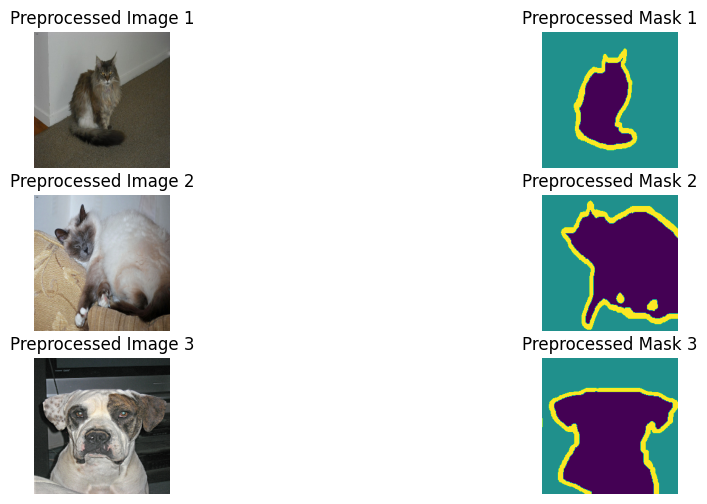

In [45]:
# Visualize preprocessed data
plt.figure(figsize=(12, 6))

for i in range(3):
    # Get a random sample from the training set
    idx = np.random.randint(0, len(x_train))

    plt.subplot(3, 2, 2*i+1)
    plt.imshow(x_train[idx])
    plt.title(f"Preprocessed Image {i+1}")
    plt.axis("off")

    plt.subplot(3, 2, 2*i+2)
    mask = np.argmax(y_train[idx], axis=-1)
    plt.imshow(mask, cmap="viridis")
    plt.title(f"Preprocessed Mask {i+1}")
    plt.axis("off")

plt.show()

---